# Regresión de precios con redes densas

**Mismo tipo de red que MNIST — tres cosas cambian:**

| | Clasificación (MNIST) | Regresión (precios) |
|---|---|---|
| Salida | 10 neuronas + softmax | 1 neurona, sin activación |
| Loss | CrossEntropy | MSE (error cuadrático medio) |
| Métrica | Accuracy (%) | MAE, RMSE (en unidades reales) |
| ¿Qué predice? | Una clase discreta | Un número continuo |

Dataset: **California Housing** — predecir el precio medio de casas
por distrito (en cientos de miles de dólares). 8 features numéricas,
20,640 muestras. Incluido en scikit-learn, sin descarga necesaria.

## 1 — Imports

In [ ]:
import numpy as np # manipulación de arrays
import matplotlib.pyplot as plt # visualización de datos
from sklearn.datasets import fetch_california_housing # dataset de regresión con 20.000 muestras y 8 características
from sklearn.model_selection import train_test_split # para dividir el dataset en entrenamiento y testeo
from sklearn.preprocessing import StandardScaler # para normalizar los datos
from sklearn.metrics import mean_absolute_error, r2_score # métricas de evaluación para regresión

import tensorflow as tf # framework de deep learning

import torch # framework de deep learning
import torch.nn as nn # para construir la arquitectura de la red
import torch.optim as optim # para optimizar los parámetros de la red
from torch.utils.data import DataLoader, TensorDataset # para manejar los datos en batches

print(f"TensorFlow: {tf.__version__}")
print(f"PyTorch:    {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo PyTorch: {device}")

TensorFlow: 2.21.0
PyTorch:    2.5.1+cu121
Dispositivo PyTorch: cuda


## 2 — Cargar y explorar el dataset

In [ ]:
housing = fetch_california_housing() # carga el dataset de California
X, y = housing.data, housing.target # X = features, y = target. precio medio en $100,000

print("Features:", housing.feature_names)
print(f"X shape: {X.shape}  →  {X.shape[0]} muestras, {X.shape[1]} features")
print(f"y shape: {y.shape}  →  precio medio en $100,000")
print(f"\nPrecio mínimo: ${y.min()*100_000:,.0f}")
print(f"Precio máximo: ${y.max()*100_000:,.0f}")
print(f"Precio medio:  ${y.mean()*100_000:,.0f}")

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X shape: (20640, 8)  →  20640 muestras, 8 features
y shape: (20640,)  →  precio medio en $100,000

Precio mínimo: $14,999
Precio máximo: $500,001
Precio medio:  $206,856


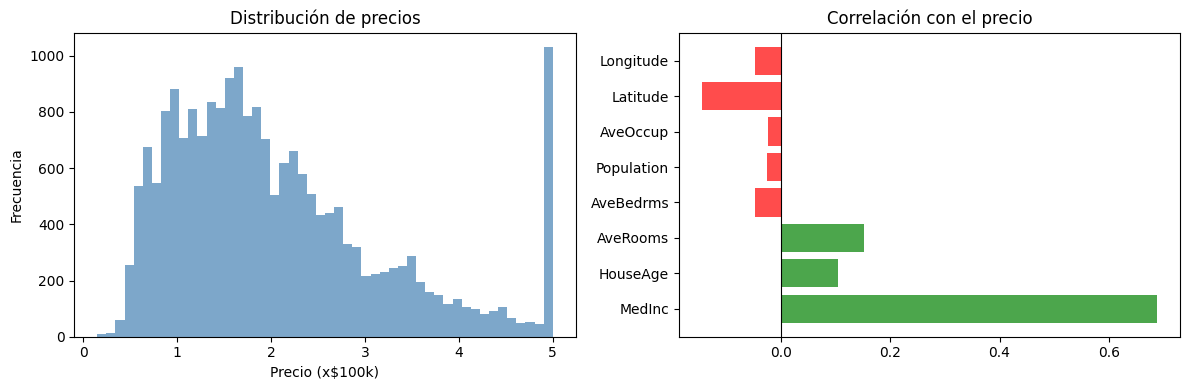

In [11]:
# Visualizar distribución de precios y correlaciones
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=50, color='steelblue', alpha=0.7) # Histograma de precios
axes[0].set_title("Distribución de precios") # Título del gráfico 
axes[0].set_xlabel("Precio (x$100k)") # Etiqueta del eje x
axes[0].set_ylabel("Frecuencia") # Etiqueta del eje y

# Correlación de cada feature con el precio
correlations = [np.corrcoef(X[:, i], y)[0, 1] for i in range(X.shape[1])] # Calcula la correlación entre cada feature y el precio
colors = ['green' if c > 0 else 'red' for c in correlations] # Verde para correlación positiva, rojo para negativa
axes[1].barh(housing.feature_names, correlations, color=colors, alpha=0.7) # Gráfico de barras horizontales de correlaciones
axes[1].set_title("Correlación con el precio") # Título del gráfico
axes[1].axvline(0, color='black', linewidth=0.8) # Línea vertical en x=0 para separar correlaciones positivas y negativas

plt.tight_layout() # Ajusta el espacio entre los subplots para que no se solapen
plt.show() # Muestra los gráficos

## 3 — Preprocesado

En datos tabulares las features tienen escalas muy distintas
(ingreso en decenas de miles, latitud en grados, población en miles...).

**StandardScaler** lleva cada feature a media=0, std=1.
Sin esto, la red converge mal o directamente no converge.

> Importante **ajusta el scaler solo con train**, aplícalo a train y test.
> Si ajustas con todo el dataset, introduces *data leakage*.

In [12]:
# Split train/test (80/20) 
X_train, X_test, y_train, y_test = train_test_split( # divide el dataset en entrenamiento y testeo
    X, y, test_size=0.2, random_state=42 
)

# Normalización: ajustar SOLO con train, aplicar a ambos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # aprende media/std de train
X_test  = scaler.transform(X_test) # aplica la misma transformación

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\nAntes de escalar — MedInc range: {housing.data[:,0].min():.1f} – {housing.data[:,0].max():.1f}")
print(f"Después de escalar — MedInc range: {X_train[:,0].min():.1f} – {X_train[:,0].max():.1f}  (media≈0, std≈1)")

Train: (16512, 8)  |  Test: (4128, 8)

Antes de escalar — MedInc range: 0.5 – 15.0
Después de escalar — MedInc range: -1.8 – 5.8  (media≈0, std≈1)


---
# TensorFlow / Keras
---

## 4A — Modelo Keras

- Añadimos **capas ocultas** con ReLU.
- La capa de salida tiene **1 neurona** sin activación (regresión).
- El loss es **MSE**.

In [13]:
tf.random.set_seed(42) # para reproducibilidad - fija la semilla del generador de números aleatorios de TensorFlow

model_keras = tf.keras.Sequential([ # modelo secuencial: capas apiladas una tras otra
    # Capas ocultas con ReLU — aprenden representaciones intermedias
    tf.keras.layers.Dense(64, activation="relu", input_shape=(8,)), # 64 neuronas, ReLU, input_shape = número de features
    tf.keras.layers.Dense(32, activation="relu"), # 32 neuronas, ReLU
    tf.keras.layers.Dense(1) # capa de salida con 1 neurona, sin activación (lineal) para regresión
])

model_keras.compile( # configura el modelo para entrenamiento
    optimizer="adam", # Adam es un optimizador eficiente
    loss="mse", # Mean Squared Error - penaliza errores grandes más que pequeños
    metrics=["mae"] # Mean Absolute Error — fácil de interpretar (en $100k)
)

model_keras.summary()

c:\Users\sebas\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history_keras = model_keras.fit( # entrena el modelo con los datos de entrenamiento
    X_train, y_train, # features y target de entrenamiento
    epochs=50, # número de veces que el modelo verá todo el dataset
    batch_size=64, # número de muestras que el modelo procesa antes de actualizar los pesos
    validation_split=0.1, # reserva el 10% de los datos de entrenamiento para validación (evaluación durante el entrenamiento)
    verbose=1 # muestra una barra de progreso durante el entrenamiento
)

# Evaluación final
test_mse, test_mae = model_keras.evaluate(X_test, y_test, verbose=0) # evalúa el modelo con los datos de testeo, devuelve MSE y MAE
y_pred_keras = model_keras.predict(X_test, verbose=0).flatten() # predice los precios con el modelo entrenado, devuelve un array de predicciones, flatten() para convertirlo a 1D
r2_keras = r2_score(y_test, y_pred_keras) # R² (coeficiente de determinación) mide qué tan bien las predicciones se ajustan a los datos reales. 1.0 = perfecto, 0 = predice siempre la media

print(f"\n=== Keras — Resultados en test ===")
print(f"MAE:  {test_mae:.4f}  →  error medio de ${test_mae*100_000:,.0f}")
print(f"RMSE: {np.sqrt(test_mse):.4f}")
print(f"R²:   {r2_keras:.4f}  (1.0 = perfecto, 0 = predice siempre la media)")

Epoch 1/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1209 - mae: 0.7399 - val_loss: 0.5581 - val_mae: 0.5357
Epoch 2/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4693 - mae: 0.4888 - val_loss: 0.4512 - val_mae: 0.4759
Epoch 3/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3982 - mae: 0.4505 - val_loss: 0.4233 - val_mae: 0.4586
Epoch 4/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3744 - mae: 0.4358 - val_loss: 0.4079 - val_mae: 0.4483
Epoch 5/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3609 - mae: 0.4269 - val_loss: 0.3962 - val_mae: 0.4406
Epoch 6/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3509 - mae: 0.4198 - val_loss: 0.3866 - val_mae: 0.4346
Epoch 7/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3417 - mae: 0.4129 - val_loss: 0.3767 - val_mae: 0.4266
Epoch 8/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3329 - mae: 0.4062 - val_loss: 0.3676 - val_mae: 0.4194
Epoch 9/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

---
# PyTorch
---

## 4B — Modelo PyTorch

In [20]:
torch.manual_seed(42) # para reproducibilidad - fija la semilla del generador de números aleatorios de PyTorch

class RegresorDenso(nn.Module): # define la arquitectura de la red neuronal para regresión
    def __init__(self):
        super().__init__()
        self.red = nn.Sequential( # secuencia de capas
            nn.Linear(8, 64), # capa de entrada con 8 features, 64 neuronas
            nn.ReLU(), # función de activación ReLU para introducir no linealidad
            nn.Linear(64, 32), # capa oculta con 32 neuronas
            nn.ReLU(), # función de activación ReLU para introducir no linealidad
            nn.Linear(32, 1) # capa de salida con 1 neurona, sin activación (lineal) para regresión
        )

    def forward(self, x): # define cómo se propagan los datos a través de la red
        return self.red(x).squeeze(1) # devuelve un tensor de forma (batch_size,) en lugar de (batch_size, 1)

model_torch = RegresorDenso().to(device) # instancia el modelo y lo mueve al dispositivo (CPU o GPU)
criterion   = nn.MSELoss() # MSELoss es la función de pérdida para regresión, penaliza errores grandes más que pequeños
optimizer_t = optim.Adam(model_torch.parameters(), lr=0.001) # Adam es un optimizador eficiente que ajusta la tasa de aprendizaje durante el entrenamiento

# Preparar DataLoaders
X_train_t = torch.tensor(X_train, dtype=torch.float32) # convierte los arrays de NumPy a tensores de PyTorch, dtype=float32 es el formato estándar para redes neuronales
y_train_t = torch.tensor(y_train, dtype=torch.float32) 
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True) # DataLoader para entrenamiento, mezcla los datos cada época (shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64) # DataLoader para testeo, no es necesario mezclar

print(model_torch)
print(f"\nParámetros totales: {sum(p.numel() for p in model_torch.parameters()):,}")

RegresorDenso(
  (red): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Parámetros totales: 2,689


In [21]:
# Bucle de entrenamiento
EPOCHS = 50 # número de épocas para entrenar el modelo
history_torch = {"train_loss": [], "val_loss": []} # diccionario para almacenar la pérdida de entrenamiento y validación en cada época

# Separar validación manualmente (equivale al validation_split=0.1 de Keras)
val_size = int(len(X_train_t) * 0.1) # tamaño del conjunto de validación (10% de los datos de entrenamiento)
X_val_t, y_val_t = X_train_t[:val_size].to(device), y_train_t[:val_size].to(device) 
X_tr_t,  y_tr_t  = X_train_t[val_size:].to(device), y_train_t[val_size:].to(device)
tr_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=64, shuffle=True)

for epoch in range(1, EPOCHS + 1):
    # --- Training ---
    model_torch.train() # pone el modelo en modo entrenamiento 
    train_loss = 0 # variable para acumular la pérdida total de entrenamiento en esta época
    for xb, yb in tr_loader: 
        optimizer_t.zero_grad()# limpia los gradientes acumulados de la iteración anterior, importante para evitar que se sumen gradientes de múltiples batches
        pred = model_torch(xb) # hace una pasada hacia adelante (forward pass) para obtener las predicciones del modelo
        loss = criterion(pred, yb) # calcula la pérdida entre las predicciones y los valores reales
        loss.backward() # calcula los gradientes de la pérdida con respecto a los parámetros del modelo
        optimizer_t.step() # actualiza los parámetros del modelo usando los gradientes calculados
        train_loss += loss.item() * len(xb) # acumula la pérdida total multiplicada por el número de muestras en el batch para obtener la pérdida total de la época
    train_loss /= len(X_tr_t) # promedio de la pérdida por muestra en esta época

    # --- Validación ---
    model_torch.eval() # pone el modelo en modo evaluación
    with torch.no_grad(): # desactiva el cálculo de gradientes para ahorrar memoria y acelerar la evaluación
        val_pred = model_torch(X_val_t) # obtiene las predicciones del modelo para el conjunto de validación
        val_loss = criterion(val_pred, y_val_t).item() # calcula la pérdida de validación y la convierte a un número de Python con .item()

    history_torch["train_loss"].append(train_loss) # almacena la pérdida de entrenamiento de esta época en el diccionario de historial
    history_torch["val_loss"].append(val_loss) # almacena la pérdida de validación de esta época en el diccionario de historial

    if epoch % 10 == 0: # cada 10 épocas, imprime el progreso del entrenamiento 
        print(f"Epoch {epoch:02d}/{EPOCHS}  loss: {train_loss:.4f}  val_loss: {val_loss:.4f}")

# Evaluación final
model_torch.eval() # pone el modelo en modo evaluación para desactivar dropout, batchnorm, etc.
with torch.no_grad(): 
    y_pred_torch = model_torch(X_test_t.to(device)).cpu().numpy() # obtiene las predicciones del modelo para el conjunto de testeo, mueve el tensor a CPU y lo convierte a NumPy

mae_torch  = mean_absolute_error(y_test, y_pred_torch) # calcula el MAE entre los valores reales y las predicciones del modelo
rmse_torch = np.sqrt(np.mean((y_test - y_pred_torch)**2)) # calcula el RMSE (Root Mean Squared Error) entre los valores reales y las predicciones del modelo, es la raíz cuadrada del MSE para tener la misma unidad que el target
r2_torch   = r2_score(y_test, y_pred_torch) # R² (coeficiente de determinación) mide qué tan bien las predicciones se ajustan a los datos reales. 1.0 = perfecto, 0 = predice siempre la media

print(f"\n=== PyTorch — Resultados en test ===")
print(f"MAE:  {mae_torch:.4f}  →  error medio de ${mae_torch*100_000:,.0f}")
print(f"RMSE: {rmse_torch:.4f}")
print(f"R²:   {r2_torch:.4f}")

Epoch 10/50  loss: 0.3344  val_loss: 0.3172
Epoch 20/50  loss: 0.2925  val_loss: 0.2946
Epoch 30/50  loss: 0.2784  val_loss: 0.2956
Epoch 40/50  loss: 0.2704  val_loss: 0.2893
Epoch 50/50  loss: 0.2657  val_loss: 0.2743

=== PyTorch — Resultados en test ===
MAE:  0.3598  →  error medio de $35,982
RMSE: 0.5372
R²:   0.7798


## 5 — Comparativa visual: curvas de loss y predicciones

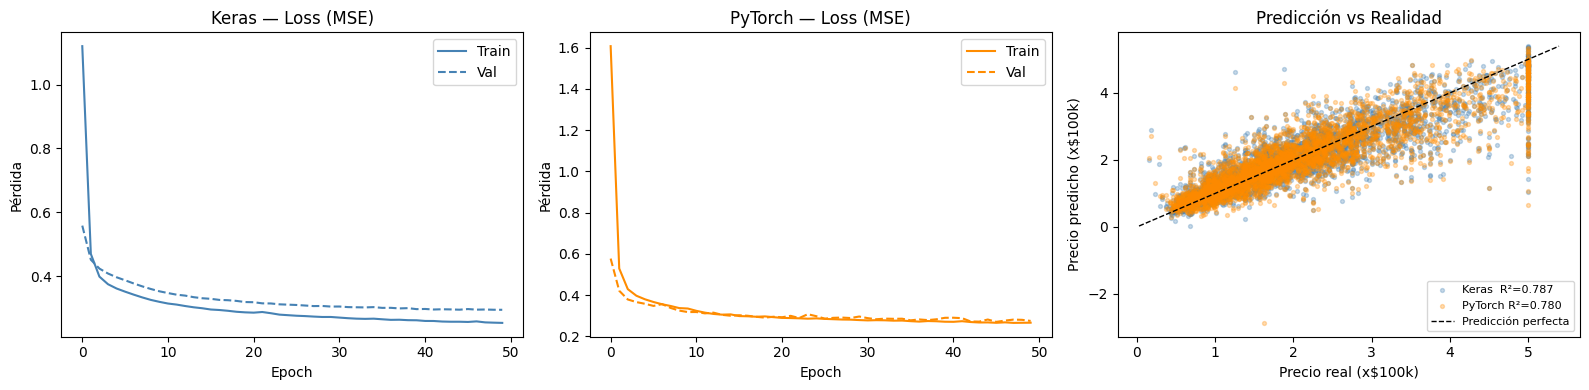

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Curvas de loss Keras ---
axes[0].plot(history_keras.history["loss"],     label="Train",  color="steelblue") # curva de pérdida de entrenamiento de Keras
axes[0].plot(history_keras.history["val_loss"], label="Val",    color="steelblue", linestyle="--") # curva de pérdida de validación de Keras
axes[0].set_title("Keras — Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Pérdida")

axes[0].legend()

# --- Curvas de loss PyTorch ---
axes[1].plot(history_torch["train_loss"], label="Train", color="darkorange")
axes[1].plot(history_torch["val_loss"],   label="Val",   color="darkorange", linestyle="--")
axes[1].set_title("PyTorch — Loss (MSE)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Pérdida")
axes[1].legend()

# --- Predicción vs Realidad (ambos modelos) ---
axes[2].scatter(y_test, y_pred_keras, alpha=0.3, s=8,  label=f"Keras  R²={r2_keras:.3f}",  color="steelblue")
axes[2].scatter(y_test, y_pred_torch, alpha=0.3, s=8,  label=f"PyTorch R²={r2_torch:.3f}", color="darkorange")
lims = [min(y_test.min(), y_pred_keras.min()), max(y_test.max(), y_pred_keras.max())]
axes[2].plot(lims, lims, 'k--', linewidth=1, label="Predicción perfecta")
axes[2].set_xlabel("Precio real (x$100k)")
axes[2].set_ylabel("Precio predicho (x$100k)")
axes[2].set_title("Predicción vs Realidad")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()